<a href="https://colab.research.google.com/github/elettra-ven/DIA-Ventura-SolAq/blob/main/SolAq_DIA_Ventura.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predizione della Solubilita Acquosa di Molecole Organiche

**Programmazione di Applicazioni Data Intensive**

Ventura Elettra - 0001117272

a.a. 2025/2026


##Obiettivo
Il progetto ha come obiettivo la **predizione della solubilità acquosa* (LogS)* di molecole organiche, a partire dalle loro proprieta fisicochimiche strutturali, utilizzando tecniche di machine learning supervisato.

##**0. Import librerie**

In [62]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

##**1. Contesto e Dataset**
### 1.1 Introduzione al problema

La **solubilita acquosa** è una proprieta fondamentale per lo studio bioinformatico delle molecole.

La solubilita e espressa come **LogS** (log10 della solubilita in mol/L):
- LogS >= 0      -> altamente solubile
- 0 > LogS >= -2 -> solubile
- -2 > LogS >= -4 -> poco solubile
- LogS < -4      -> insolubile

### 1.2 Dataset e fonti

**AqSolDB** (Kaggle:https://www.kaggle.com/datasets/sorkun/aqsoldb-a-curated-aqueous-solubility-dataset) è stato pubblicato da Sorkun et al. su *Scientific Data* nel 2019.

È costruito fondendo **9 dataset sperimentali** con un algoritmo di curation che seleziona il valore piu affidabile.
- **Dimensione:** 9.982 molecole uniche
- **Target:** LogS - valore sperimentale di solubilita acquosa

In [63]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sorkun/aqsoldb-a-curated-aqueous-solubility-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'aqsoldb-a-curated-aqueous-solubility-dataset' dataset.
Path to dataset files: /kaggle/input/aqsoldb-a-curated-aqueous-solubility-dataset


In [64]:
df = pd.read_csv(os.path.join(path, "curated-solubility-dataset.csv")) # DataFrame da file
print("Righe: ",df.shape[0])
print("Colonne: ",df.shape[1])
df.head()

Righe:  9982
Colonne:  26


,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",InChI=1S/C21H46N.BrH/c1-5-6-7-8-9-10-11-12-13-...,SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,0.0,1,G1,392.510,...,17.0,142.0,0.0,0.0,0.0,0.0,0.00,158.520601,0.000000e+00,210.377334
1,A-4,Benzo[cd]indol-2(1H)-one,InChI=1S/C11H7NO/c13-11-8-5-1-3-7-4-2-6-9(12-1...,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,0.0,1,G1,169.183,...,0.0,62.0,2.0,0.0,1.0,3.0,29.10,75.183563,2.582996e+00,511.229248
2,A-5,4-chlorobenzaldehyde,InChI=1S/C7H5ClO/c8-7-3-1-6(5-9)2-4-7/h1-5H,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,0.0,1,G1,140.569,...,1.0,46.0,1.0,0.0,0.0,1.0,17.07,58.261134,3.009782e+00,202.661065
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",InChI=1S/2C23H22O3.Zn/c2*1-15(17-9-5-3-6-10-17...,XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,0.0,1,G1,756.226,...,10.0,264.0,6.0,0.0,0.0,6.0,120.72,323.755434,2.322963e-07,1964.648666
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,InChI=1S/C25H30N2O4/c1-5-20(26(10-22-14-28-22)...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,0.0,1,G1,422.525,...,12.0,164.0,2.0,4.0,4.0,6.0,56.60,183.183268,1.084427e+00,769.899934


###1.3 Descrizione delle variabili

Il dataset contiene le seguenti variabili:

1. **`ID`** *(stringa)*: Identificatore univoco della molecola.
2. **`Name`** *(stringa)*: Nome IUPAC ufficiale della struttura chimica.
3. **`InChI`** *(stringa)*: Rappresentazione chimica internazionale standard.
4. **`InChIKey`** *(stringa)*: Hash compatto a lunghezza fissa della struttura InChI.
5. **`SMILES`** *(stringa)*: Notazione lineare *machine readable* utilizzata per descrivere la struttura molecolare.
6. **`Solubility`** *(float)*: **TARGET** LogS = log10 della solubilità espressa in mol/L.
7. **`SD`** *(float)*: Deviazione standard.
8. **`Occurrences`** *(int)*: Numero di dataset originali in cui compare la molecola.
9. **`Group`** *(stringa)*: Etichetta di affidabilità della misurazione effettuata (meta-dato).
10. **`MolWt`** *(float)*: Peso molecolare complessivo espresso in Dalton.
11. **`MolLogP`** *(float)*: Lipofilia, ovvero affinità per i grassi rispetto all'acqua.
12. **`MolMR`** *(float)*: Rifrazione molare, ovvero misura della polarizzabilità globale della molecola.
13. **`TPSA`** *(float)*: Superficie polare topologica, ovvero area delle regioni polari molecolari.
14. **`LabuteASA`** *(float)*: Area di superficie molecolare accessibile al solvente calcolata secondo il modello di Labute.
15. **`HeavyAtomCount`** *(int)*: Numero di atomi non-idrogeno ("pesanti") presenti nel sistema.
16. **`NumHAcceptors`** *(int)*: Accettori di legami idrogeno.
17. **`NumHDonors`** *(int)*: Donatori di legami idrogeno.
18. **`NumHeteroatoms`** *(int)*: Numero di eteroatomi (atomi diversi da Carbonio e Idrogeno) nel nucleo molecolare.
19. **`NumRotatableBonds`** *(int)*: Legami ruotabili, ovvero indice della flessibilità di rotazione della struttura.
20. **`NumValenceElectrons`** *(int)*: Numero complessivo di elettroni di valenza.
21. **`NumAromaticRings`** *(int)*: Numero di anelli aromatici presenti.
22. **`NumSaturatedRings`** *(int)*: Numero di anelli completamente saturi.
23. **`NumAliphaticRings`** *(int)*: Numero totale di anelli alifatici presenti.
24. **`RingCount`** *(int)*: Numero totale di anelli.
25. **`BalabanJ`** *(float)*: Indice di connettività topologica di Balaban.
26. **`BertzCT`** *(float)*: Indice topologico di Bertz per la quantificazione della complessità strutturale.

##1.4 Prima scrematura dei dati
Rimuoviamo le colonne che non contengono informazioni predittive ("meta-dati" e identificatori):
- `ID`, `Name`, `InChI`, `InChIKey`, `SMILES`: sono tutti **identificatori** e non portano particolari informazioni sulla struttura
- `SD`: **deviazione standard** delle misurazioni effettuate da diverse fonti
- `Occurrences`: numero di occorrenze di un composto
- `Group`: etichetta meta-dato per l'affidabilità

In [65]:
# Individuo le colonne da rimuovere
cols_to_drop = ["ID", "Name", "InChI", "InChIKey", "SMILES",
                "SD", "Ocurrences", "Group"]

df = df.drop(columns=cols_to_drop)

print("Righe dopo scrematura: ",df.shape[0])
print("Colonne dopo scrematura: ",df.shape[1])

Righe dopo scrematura:  9982
Colonne dopo scrematura:  18


In [66]:
print("Tipi di dati: ", df.dtypes.to_string())

Tipi di dati:  Solubility             float64
MolWt                  float64
MolLogP                float64
MolMR                  float64
HeavyAtomCount         float64
NumHAcceptors          float64
NumHDonors             float64
NumHeteroatoms         float64
NumRotatableBonds      float64
NumValenceElectrons    float64
NumAromaticRings       float64
NumSaturatedRings      float64
NumAliphaticRings      float64
RingCount              float64
TPSA                   float64
LabuteASA              float64
BalabanJ               float64
BertzCT                float64


Rimangono 18 variabili nel dataset, di queste:
- 1 è il target
- 7 sono variabili **continue** (*float*)
- 10 sono variabili che, secondo le indicazione del dataset, rappresentano conteggi **discreti**

Ma come abbiamo notato, i dati sono stati caricati tutti come `float64`.
Effettuiamo la conversione per mantenere consistenza semantica nella differenziazione tra viariabili **discrete** e **continue**.

In [67]:
features_discrete = [
    'HeavyAtomCount', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms',
    'NumRotatableBonds', 'NumValenceElectrons', 'NumAromaticRings',
    'NumSaturatedRings', 'NumAliphaticRings', 'RingCount'
]
df[features_discrete] = df[features_discrete].astype('int64')

print("Nuova verifica dei tipi di dato:")
print(df.dtypes.to_string())

Nuova verifica dei tipi di dato:
Solubility             float64
MolWt                  float64
MolLogP                float64
MolMR                  float64
HeavyAtomCount           int64
NumHAcceptors            int64
NumHDonors               int64
NumHeteroatoms           int64
NumRotatableBonds        int64
NumValenceElectrons      int64
NumAromaticRings         int64
NumSaturatedRings        int64
NumAliphaticRings        int64
RingCount                int64
TPSA                   float64
LabuteASA              float64
BalabanJ               float64
BertzCT                float64


##**2. Analisi Esplorativa del Dataset (EDA)**


###2.1 Statistiche descrittive


In [69]:
df.describe().round(3)

,Solubility,MolWt,MolLogP,MolMR,HeavyAtomCount,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
count,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000
mean,-2.890,266.666,1.979,66.795,17.375,3.487,1.109,5.197,4.073,94.243,1.068,0.293,0.448,1.516,62.459,108.913,2.392,467.337
std,2.368,184.179,3.518,46.523,12.242,3.498,1.489,4.736,5.647,64.749,1.309,0.880,1.055,1.644,63.348,76.463,1.091,546.632
min,-13.172,9.012,-40.873,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,7.504,-0.000,0.000
25%,-4.326,162.276,0.620,40.602,11.000,2.000,0.000,3.000,1.000,58.000,0.000,0.000,0.000,0.000,26.300,66.624,2.004,163.243
50%,-2.618,228.682,1.949,58.633,15.000,3.000,1.000,4.000,3.000,82.000,1.000,0.000,0.000,1.000,50.720,93.300,2.540,351.640
75%,-1.210,320.436,3.419,81.938,21.000,4.000,2.000,6.000,5.000,112.000,2.000,0.000,1.000,2.000,80.390,129.118,3.032,606.563
max,2.138,5299.456,68.541,1419.352,388.000,86.000,26.000,89.000,141.000,2012.000,35.000,30.000,30.000,36.000,1214.340,2230.685,7.517,20720.268


##2.2 Verifica dei Valori Nulli (NaN)

In [70]:
nan_counts = df.isna().sum()
if nan_counts.sum() == 0:
  print("Non ci sono valori nulli nel dataset.")
else:
  print("Valori nulli per colonna:", nan_counts[nan_counts>0])

Non ci sono valori nulli nel dataset.


Il dataset è privo di valori NaN, quindi non è necessario sostituirli o eliminarli.

##2.3 Distribuzione del target (solubilità LogS)
Analizziamo la distribuzione della variabile target tramite **istogramma** e **box plot**.

La scala di riferimento per interpretare correttamente i valori è:
- LogS >= 0: altamente solubile
- -2 <= LogS < 0: solubile
- -4 <= LogS < -2: poco solubile
- LogS < -4: insolubile

In [72]:
solubility_data = df["Solubility"]
mean_sol = solubility_data.mean()
median_sol = solubility_data.median()

sol_class_labels = [
    "Insolubile (LogS < -4)",
    "Poco sol. (-4, -2]",
    "Solubile (-2, 0]",
    "Molto sol. (> 0)"
]

classi_sol = pd.cut(
    solubility_data,
    bins=[-float("inf"), -4, -2, 0, float("inf")],
    labels=sol_class_labels
)

print("Metriche calcolate!")

Metriche calcolate!


In [73]:
print("Distribuzione per classe di solubilità:")
df_classi = classi_sol.value_counts().sort_index().to_frame(name="")
display(df_classi)

print(f"\nMedia: {df['Solubility'].mean():.3f}")
print(f"Mediana: {df['Solubility'].median():.3f}")
print(f"Min: {df['Solubility'].min():.3f}")
print(f"Max: {df['Solubility'].max():.3f}")

Distribuzione per classe di solubilità:


,
Solubility,
Insolubile (LogS < -4),2879
"Poco sol. (-4, -2]",3207
"Solubile (-2, 0]",2840
Molto sol. (> 0),1056



Media: -2.890
Mediana: -2.618
Min: -13.172
Max: 2.138


Possiamo notare che i valori di **media** e **mediana** sono tra loro abbastanza viine, dando alla variabile una distribuzione **lievemente simmetrica**.

La classe più frequente è "**Poco solubile**", con valori tra -4 e -2.

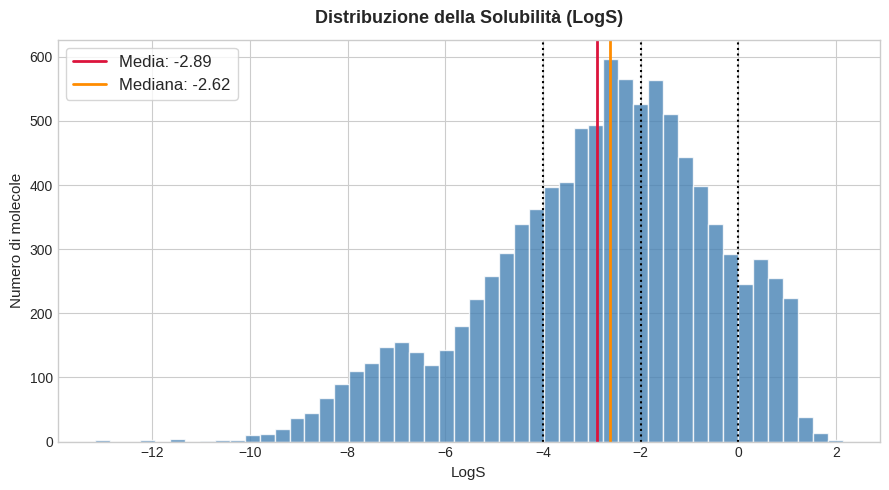

In [79]:
plt.figure(figsize=(9, 5))

plt.hist(solubility_data, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
plt.axvline(mean_sol, color="crimson", linestyle="-", linewidth=2, label=f"Media: {mean_sol:.2f}")
plt.axvline(median_sol, color="darkorange", linestyle="-", linewidth=2, label=f"Mediana: {median_sol:.2f}")

soglie = [-4,-2,0]
for soglia in soglie:
    plt.axvline(soglia, color="black", linestyle=":", linewidth=1.5)

plt.title("Distribuzione della Solubilità (LogS)", fontsize=13, pad=12, fontweight='bold')
plt.xlabel("LogS", fontsize=11)
plt.ylabel("Numero di molecole", fontsize=11)
plt.legend(loc="upper left", frameon=True, fontsize=12)

plt.tight_layout()
plt.show()

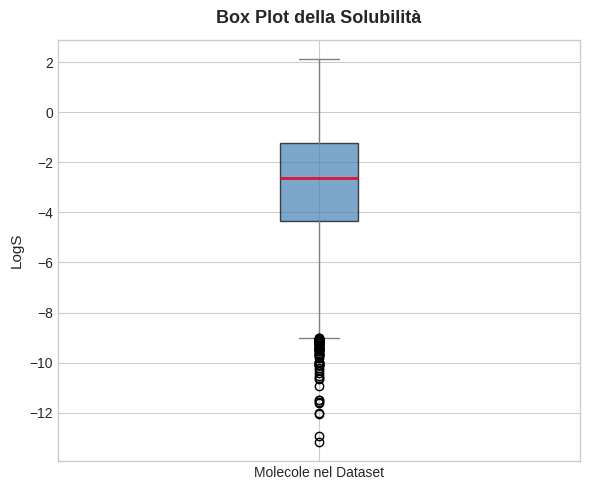

In [81]:
plt.figure(figsize=(6, 5))

plt.boxplot(
    solubility_data,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.7, edgecolor="black"),
    medianprops=dict(color="crimson", linewidth=2),
    whiskerprops=dict(color="gray"),
    capprops=dict(color="gray")
)

plt.title("Box Plot della Solubilità", fontsize=13, pad=12, fontweight='bold')
plt.xticks([1], ["Molecole nel Dataset"])

plt.ylabel("LogS", fontsize=11)

plt.tight_layout()
plt.show()

Il grafico a barre mostra una distribuzione semi-normale, centrata intorno ai valori di media e mediana (che hanno tra loro minima discrepanza).

Notiamo un'assimetria nella forma di una "coda sinistra" più pronunciata nell'istogramma e degli outlier evidenti nel box-plot, che riflettono la presenza di composti assolutamente insolubili ($LogS < -8$).

##2.4 Distribuzione delle feature
L'obiettivo di questa analisi è capire se le distribuzioni dei predittori presentano asimmetrie, bassa varianza, valori anomali e/o numerosi zeri, per poter poi lavorare sulle correlazioni.

###2.4.1 Feature continue

In [82]:
features_continuous = [
    'MolWt', 'MolLogP', 'MolMR', 'TPSA', 'LabuteASA', 'BalabanJ', 'BertzCT'
]

In [83]:
def plot_features_his(features, title):
    num_feat = len(features)
    if num_feat == 0:
        print("Nessuna feature fornita.")
        return

    n_cols = 2
    n_rows = (num_feat + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))

    if num_feat == 1:
        axes_flat = np.array([axes])
    else:
        axes_flat = axes.ravel()

    for i, col in enumerate(features):
        ax = axes_flat[i]
        ax.hist(df[col], bins=50, color="steelblue", edgecolor="white", alpha=0.75)

        mean_val = df[col].mean()
        ax.axvline(mean_val, color="crimson", linestyle="--", linewidth=1.5,
                   label=f"Media: {mean_val:.2f}")

        ax.set_title(col, fontsize=16, fontweight="bold", pad=10)
        ax.set_xlabel("Valore", fontsize=12)
        ax.set_ylabel("Frequenza", fontsize=12)
        ax.tick_params(labelsize=11)
        ax.legend(fontsize=11, loc="upper right")

    for j in range(i + 1, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.suptitle(title, fontsize=18, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

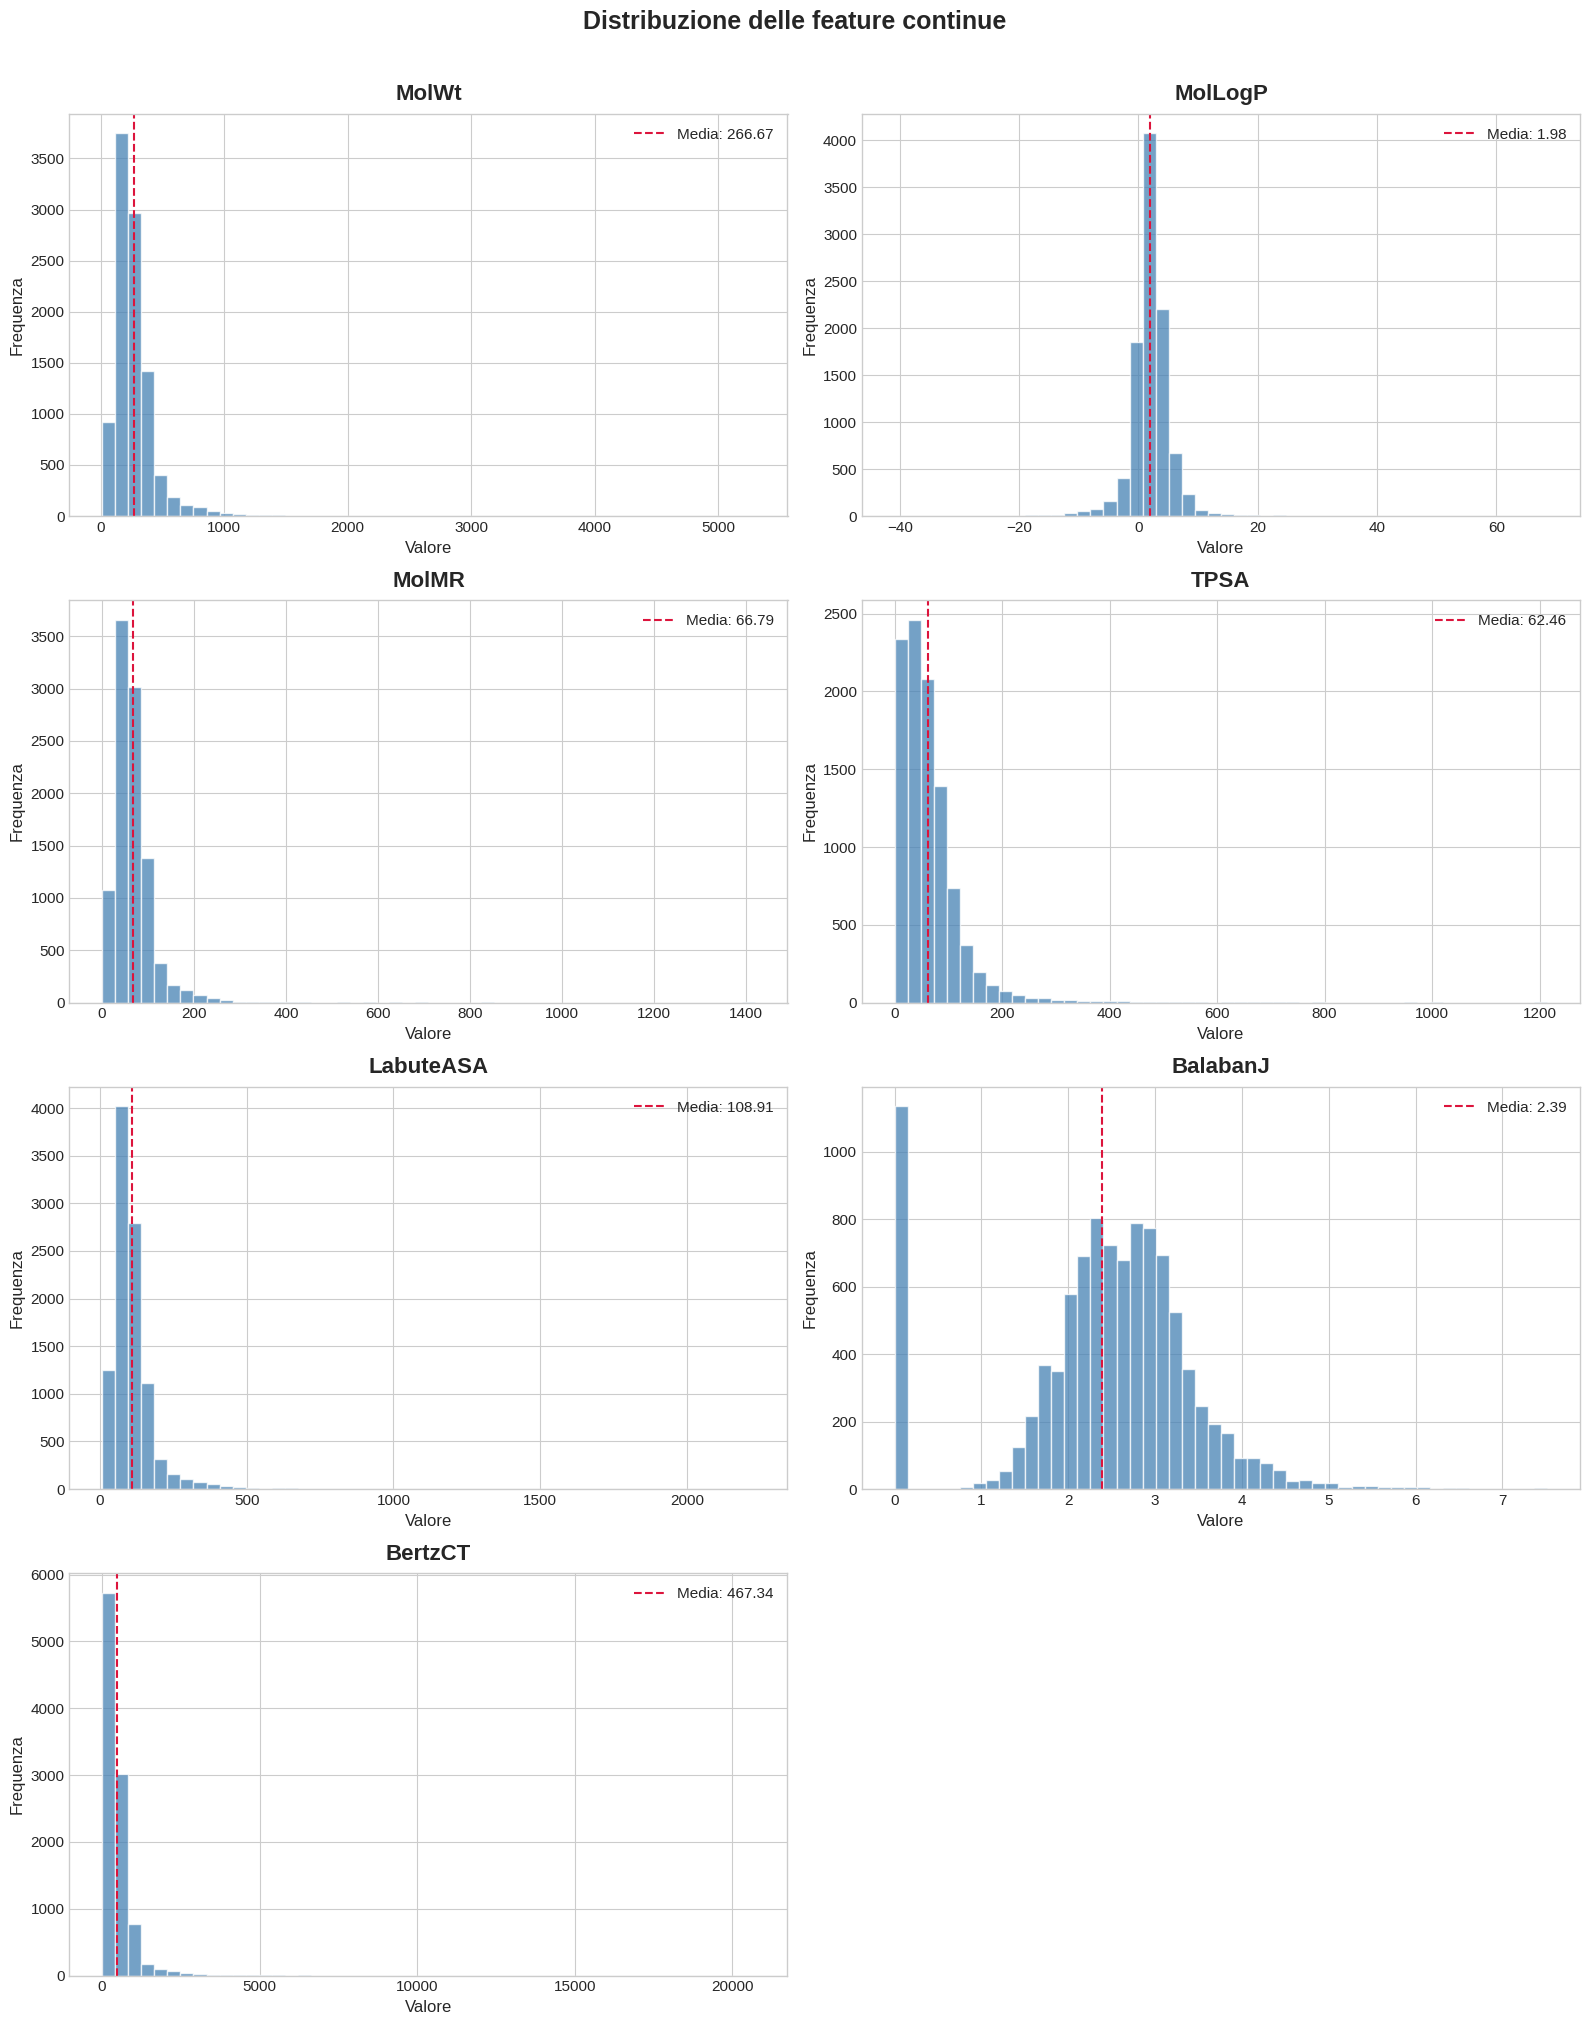

In [84]:
plot_features_his(features_continuous, "Distribuzione delle feature continue")

###2.4.2 Feature discrete

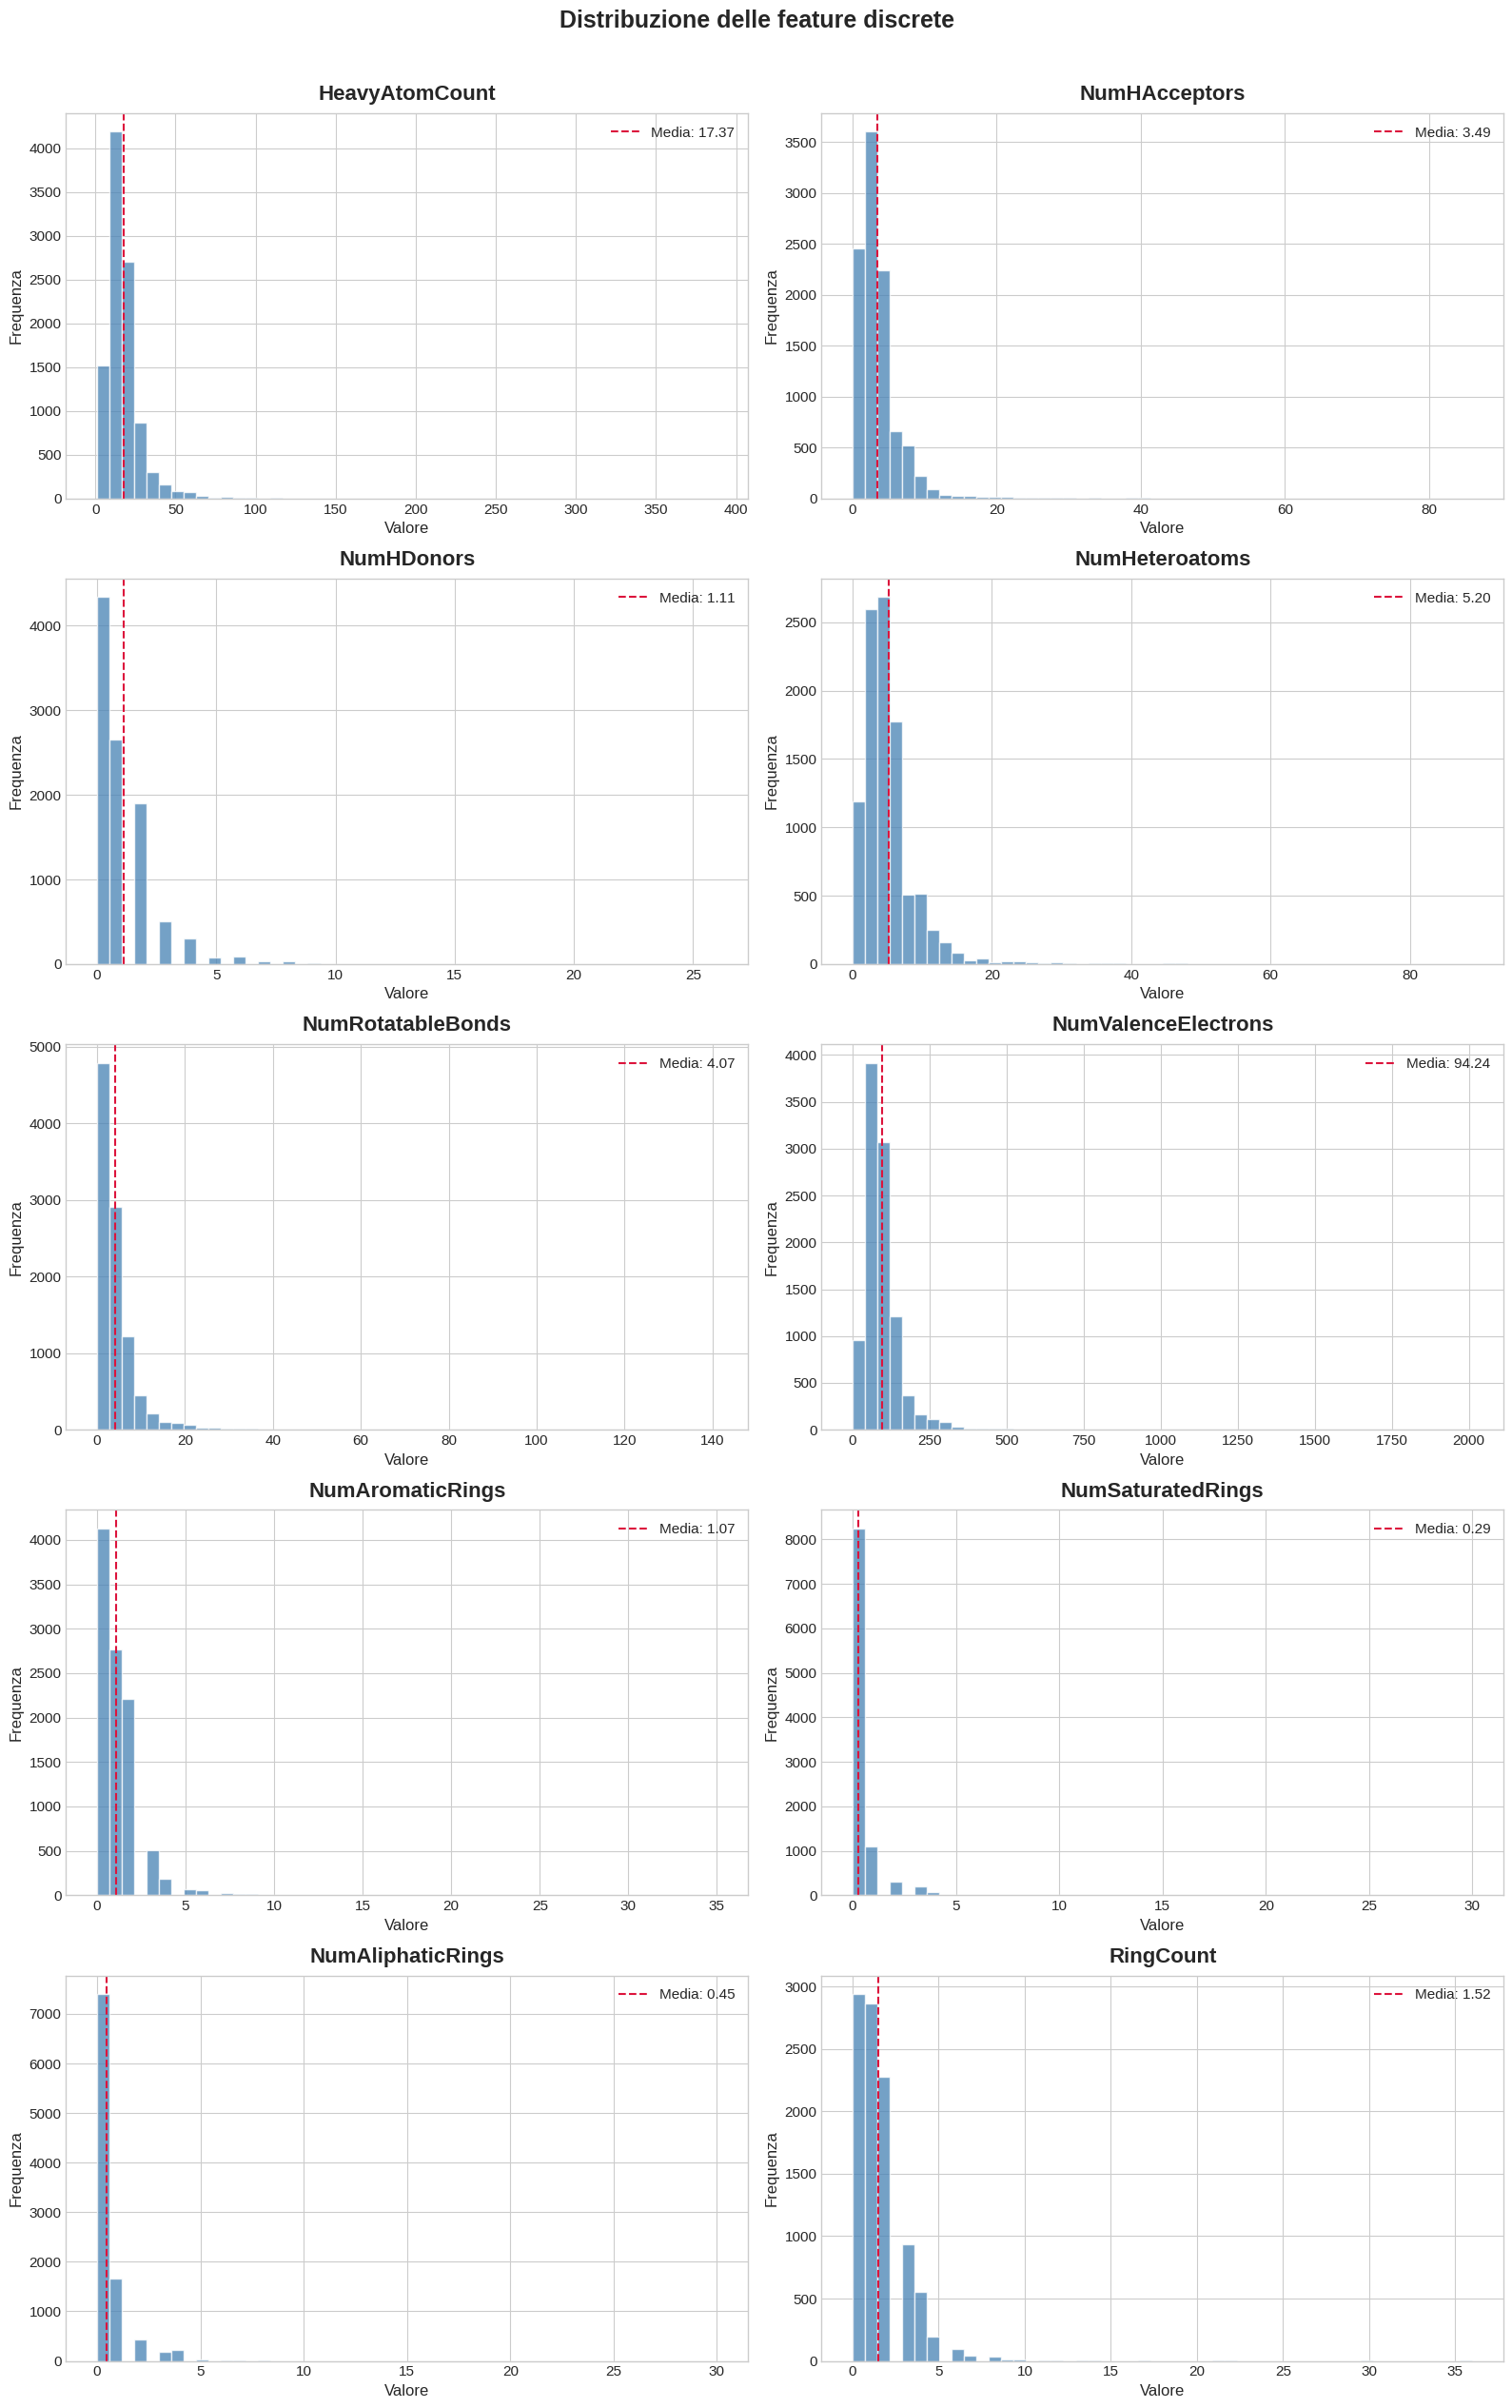

In [85]:
plot_features_his(features_discrete, "Distribuzione delle feature discrete")

Come visibile dagli istogrammi, molte feature presentano asimmetrie con code sbilanciate.

Questo renderà necessario analizzare gli **outliers** nel prossimo step dell'analisi.

###2.4.3 Varianza delle features
Vogliamo ora capire quali feature siano a più bassa varianza, ovvero quali abbiano i valori più costanti e potenzialmente poco informativi.

In [88]:
var_feat = df.drop(columns=["Solubility"]).var().sort_values()
var_feat.head(5).round(3).to_frame(name="Varianza")

,Varianza
NumSaturatedRings,0.774
NumAliphaticRings,1.112
BalabanJ,1.191
NumAromaticRings,1.715
NumHDonors,2.217


Queste varianze (le più basse) rimangono significative rispetto al range di valori in cui operano queste cinque features (circa tra 0 e 10), quindi non è giustificata la loro rimozione nell'ottica di predirre correttamente $LogS$.

##2.5 Outliers (valori estremi)


In [90]:
features = df.drop(columns=["Solubility"])
Q1 = features.quantile(0.25)
Q3 = features.quantile(0.75)
IQR = Q3 - Q1

outliers = (features < (Q1 - 1.5 * IQR)) | (features > (Q3 + 1.5 * IQR))
df_outliers = outliers.sum().sort_values().to_frame(name="Numero Outlier (IQR)")

display(df_outliers)

,Numero Outlier (IQR)
NumAromaticRings,115
NumHDonors,188
RingCount,223
BertzCT,441
MolMR,455
TPSA,472
NumAliphaticRings,479
HeavyAtomCount,480
MolWt,488
NumValenceElectrons,504


**Considerazioni:**

Per calcolare il numero di **outlier** è stato utilizzato il criterio dell'Intervallo Interquartile ($IQR$) che, in questo caso, ha rilevato un numero cospiquo di estremi statistici su quasi tutti i predittori.

Questi valori (particolarmente alti in MolWt, BalabanJ, NumSaturatedRings) sono giustificati dalla presenza di composti molecolari reali aventi proprietà strutturali e geometriche effettivamente complesse o insolite, piuttosto che da errori nei dati. Di conseguenza, la rimozione di questi record comprometterebbe la capacità dei modelli di generalizzare correttamente su questo tipo di strutture rare.

Allo stesso modo, gli outlier nel target ($LogS < -10$) rappresentano molecole realmente insolubili e vengono mantenuti.

##2.6 Correlazione tra features

Questo step dell'analisi ha come obiettivo l'identificazione delle proprietà molecolari che effettivamente sono utili per la predizione della solubilità:
studiando le relazioni lineari possibili tra predittori e target e tra i predittori stessi, sarà possibile verificare l'eventuale presenza di forti correlazioni, che potrebbero introdurre informazioni ridondanti.
> Siccume lavoriamo con variabili quantitative, con un'unità di misura numerica definita, utilizziamo nuovamente la **correlazione di Pearson** e la mostriamo tramite matrice.




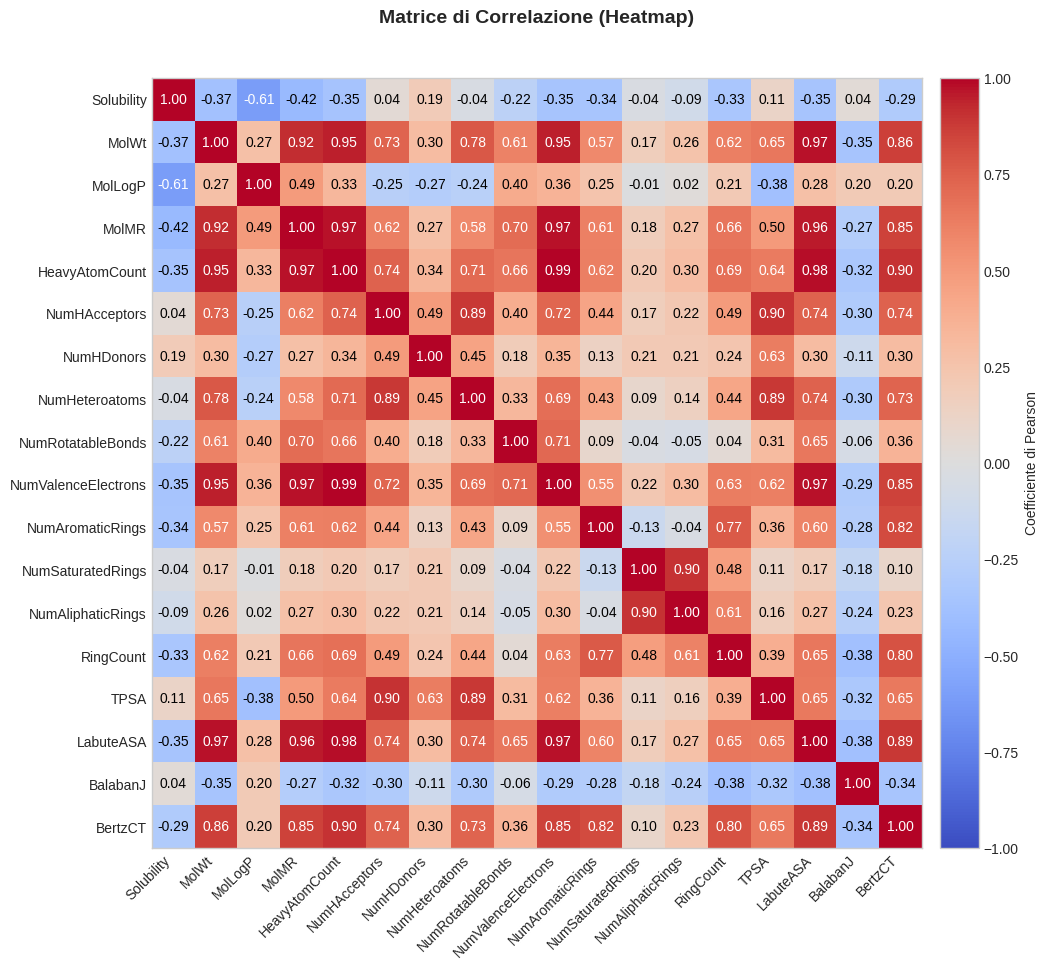

In [91]:
corr_mat = df.corr(method = "pearson")
columns = corr_mat.columns

fig,ax = plt.subplots(figsize=(12,10))

cax = ax.imshow(corr_mat.values, cmap="coolwarm", vmin=-1, vmax=1)

ax.figure.colorbar(cax, ax=ax, label="Coefficiente di Pearson",pad=0.02)
ax.set_xticks(np.arange(len(columns)))
ax.set_yticks(np.arange(len(columns)))
ax.set_xticklabels(columns, rotation=45, ha="right")
ax.set_yticklabels(columns)

for (i, j), val in np.ndenumerate(corr_mat.values):
    ax.text(j, i, f"{val:.2f}", ha="center", va="center",
            color="white" if abs(val) > 0.5 else "black")

ax.grid(False)
plt.title("Matrice di Correlazione (Heatmap)", fontsize=14, fontweight="bold", pad=40)
plt.show()


###2.6.1 Analisi correlazione feature-feature
Dopo un'attenta analisi, vediamo che la heatmap rivela una forte correlazione tra alcuni gruppi di variabili:

> Nei riquadri rossi (esclusa la diagonale) notiamo in particolare che le variabili che descrivono a grandi linee la dimensione del composto (quindi `MolWt`, `MolMR`, `HeavyAtomCount` e `NumValenceElectrons`) sono collegate con punteggi molto alti $r>0,9$ che segnalano una forte ridondanza.

Abbiamo anche altri picchi elevati per alcune coppie di variabili come `MolWt` e `LabuteASA`, per esempio.

####**Considerazioni IMPORTANTI:**

si sceglie deliberatamente di **non rimuovere** manualmente queste feature. La ridondanza informativa verrà gestita direttamente in fase di modellazione sfruttando le funzioni di *penalty* dei modelli.

###2.6.2 Analisi correlazione feature-target
Concentriamoci sulla colonna della matrice relativa al target `LogS`:

In [92]:
display(corr_mat['Solubility'].drop("Solubility").sort_values().round(3).to_frame(name="Pearson r"))

,Pearson r
MolLogP,-0.609
MolMR,-0.424
MolWt,-0.368
HeavyAtomCount,-0.353
LabuteASA,-0.349
NumValenceElectrons,-0.346
NumAromaticRings,-0.343
RingCount,-0.330
BertzCT,-0.289
NumRotatableBonds,-0.222


Vogliamo ora visualizzare la correlazione tra le feature con correlazione a impatto più **negativo** (`MolLogP`) e più **positivo** (`NumHDonors`) nei confronti del target.

L'analisi di Pearson effettuata nel punto precedente è stata in grado di valutare le relazioni solo assumendole lineari, non cogliendo i possibili pattern più complessi tra target e feature.

Introduciamo lo Scatter Plot per verificare visivamente la forma delle distribuzioni e la presenza di vincoli strutturali.

>Al fine di arricchire l'esplorazione è stato integrato il **peso molecolare** (`MolWt`) come "terza dimensione" del grafico, espressa come intensità cromatica:

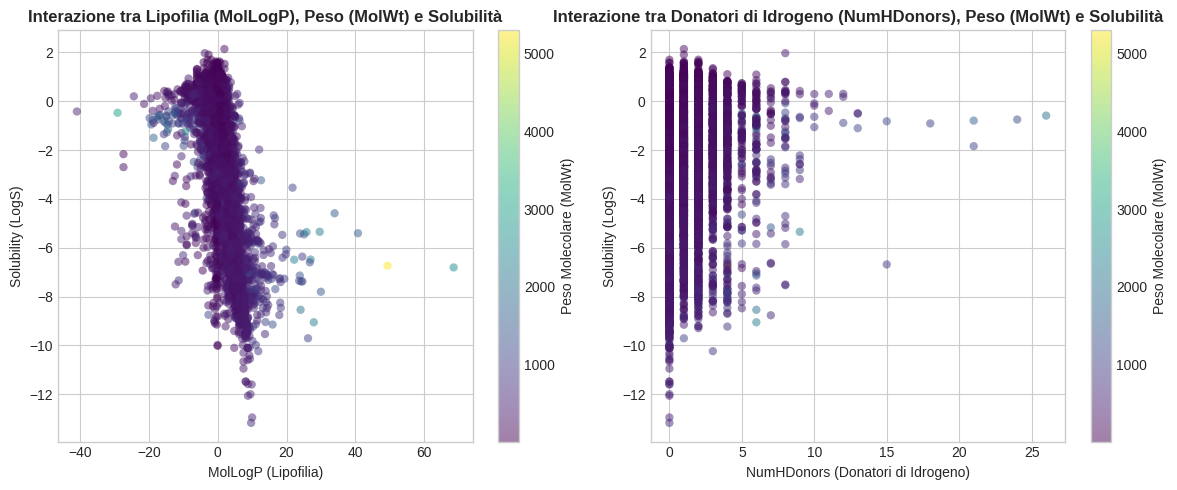

In [93]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
scatter1 = ax1.scatter(df["MolLogP"], df["Solubility"], c=df["MolWt"], cmap="viridis", alpha=0.5, edgecolor="none")
ax1.set_title("Interazione tra Lipofilia (MolLogP), Peso (MolWt) e Solubilità", fontsize=12, fontweight="bold")
ax1.set_xlabel("MolLogP (Lipofilia)")
ax1.set_ylabel("Solubility (LogS)")
fig.colorbar(scatter1, ax=ax1, label="Peso Molecolare (MolWt)")

scatter2 = ax2.scatter(df["NumHDonors"], df["Solubility"], c=df["MolWt"], cmap="viridis", alpha=0.5, edgecolor="none")
ax2.set_title("Interazione tra Donatori di Idrogeno (NumHDonors), Peso (MolWt) e Solubilità", fontsize=12, fontweight="bold")
ax2.set_xlabel("NumHDonors (Donatori di Idrogeno)")
ax2.set_ylabel("Solubility (LogS)")
fig.colorbar(scatter2, ax=ax2, label="Peso Molecolare (MolWt)")
plt.tight_layout()
plt.show()

>Nel **primo grafico** possiamo notare alcuni outlier per quanto riguarda la Lipofilia, infatti appaiono dei punti a MolLogP minori di $-20$ e maggiori di $+40$, che non sono valori sostenibili biologicamente e che quindi rappresentano errori del dataset.

Già questo elemento da solo è un segnale che questi record sarebbero insadatti a una regressione lineare classica, poiché gli errori sarebbero amplificati dai minimi quadrati.

>In **entrambi i grafici** possiamo confermare l'andamento dell'istogramma riguardante la feature del peso molecolare: questo già mostrava un andamento pseudo-normale con forte asimetria e predilezione per molecole piccole (biologicamente questo è giustificato dal fatto che molte molecole coinvolte negli studi che hanno prodotto il dataset sono composti farmacologici, di solito molto sotto i $1000 Da$)

Le macromolecole di grandi dimensioni sono rarissime e indicate dai punti gialli/verdi.

>Nel **secondo grafico** analizziamo che, con l'aumentare dei donatori di idrogeno, la solubilità tende ad aumentare, in particolare, l'insolubilità assoluta ($LogS < -4$) diventa sempre più rara man mano che ci si sposta verso destra.
Possiamo quindi ipotizzare una correlazione tra le due feature (dovuta ai legami a idrogeno che si formano tra i gruppi* dei donatori e $H_2O$).


*I donatori di idrogeno hanno gruppi contententi $H$, come $-OH$ e $-NH$.

##2.9 Conclusioni della EDA
L'analisi esplorativa ha delineato la struttura del dataset, evidenziando aspetti cruciali per la preparazione dei dati e per la scelta dei modelli:

* Si tratta di un dataset piuttosto ricco e descrittivo di 18 variabili, alcune delle quali mostrano dei gruppi di **collinearità** multipla molto alta.
> Si è scelto di preservare queste informazioni, anche se potenzialmente ridondanti, poiché verranno regolarizzati automaticamente dai modelli a regressione con penalità.

* Sono presenti outlier molto alti, che potrebbero far pensare a errori di laboratorio e che generano code nelle distribuzioni delle feature.
> Ancora una volta si decide di non eliminare le variabili per garantire la massima rappresentatività dello spazio chimico. L'impatto di questi outlier sarà gestito nella preparazione dei dati e dalla robustezza dei modelli.



---



##**3. Preparazione dei dati**

##**4. Addestramento e validazione**

##**5. Ricerca degli iper-parametri**